# Splice site evaluation over a BED file

Runs splice-site classification predictions over all (or a subset of) windows
defined by a BED file and aggregates AUPRC, confusion counts, and PR curves
across the full set.

## Configuration

In [1]:
# ── Paths ──────────────────────────────────────────────────────────────────
genome      = "/home/elek/sds/sd17d003/Anamaria/genomes/ensembl115/fasta/Homo_sapiens.fa"
bed_file    = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/folds_100kb/FOLD_0_subset/test.bed"
annotation  = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/splice_sites.parquet"
usage_file  = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/usage.parquet"
checkpoint  = "/home/elek/projects/alphagenome_ft_pytorch/checkpoints/model_fold_0.safetensors"

# ── Settings ────────────────────────────────────────────────────────────────
device      = "cuda"
organism    = 0          # 0 = human, 1 = mouse
seq_len     = 131072
max_windows = 100         # set to None to run all windows in the BED file

# ── Labels / colours (shared across cells) ─────────────────────────────────
SPLICE_CLASS_NAMES = ["Donor+", "Acceptor+", "Donor-", "Acceptor-"]
BACKGROUND_CLASS   = 4
CLASS_LABELS  = {0: 'donor +', 1: 'acceptor +', 2: 'donor -', 3: 'acceptor -', 4: 'no splice site'}
CLASS_COLORS  = {0: '#ff7f00', 1: '#33a02c', 2: '#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}

## Load model and annotations

In [2]:
import numpy as np
import pandas as pd
import torch
from alphagenome_pytorch.utils.model_loading import load_model_for_inference

model, cfg = load_model_for_inference(checkpoint, device, strict=False)
model.eval()
print(f"Model loaded from: {checkpoint}")

Model loaded from: /home/elek/projects/alphagenome_ft_pytorch/checkpoints/model_fold_0.safetensors


In [3]:
import pyfaidx
from alphagenome_pytorch.utils.sequence import sequence_to_onehot

fasta   = pyfaidx.Fasta(genome, as_raw=True, sequence_always_upper=True)
annot   = pd.read_parquet(annotation)
annot["Chromosome"] = annot["Chromosome"].astype(str)
usage   = pd.read_parquet(usage_file)

# Read BED windows
half = seq_len // 2
windows = []
with open(bed_file) as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue
        parts = line.strip().split()
        chrom  = parts[0]
        center = (int(parts[1]) + int(parts[2])) // 2
        windows.append((chrom, center - half, center + half))

if max_windows is not None:
    windows = windows[:max_windows]

print(f"Loaded {len(windows)} windows from {bed_file}")

Loaded 100 windows from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/folds_100kb/FOLD_0_subset/test.bed


## Splice site classification

In [4]:
from sklearn.metrics import average_precision_score, precision_recall_curve
from alphagenome_pytorch.utils.sequence import sequence_to_onehot
from tqdm.auto import tqdm

# Label mapping: SiteType string → class index
label_to_idx = {name: i for i, name in enumerate(SPLICE_CLASS_NAMES)}
n_classes = len(SPLICE_CLASS_NAMES) + 1  # 4 splice + 1 background

# Organism tensor (re-used every iteration)
org_t = torch.full((1,), organism, dtype=torch.long, device=device)

all_probs        = []   # list of (L, n_classes) arrays for all positions
all_true_classes = []   # list of (L,) int arrays for all positions
all_alphas       = []   # list of dicts {alpha, correct}

model.eval()
with torch.no_grad():
    for chrom_w, start_w, end_w in tqdm(windows, desc="Windows"):
        # ── Extract and encode sequence ────────────────────────────────
        try:
            seq = fasta[chrom_w][start_w:end_w]
        except Exception:
            continue
        if len(seq) != seq_len:
            continue
        seq_np = sequence_to_onehot(seq).astype(np.float32)   # (L, 4)
        seq_t  = torch.from_numpy(seq_np).unsqueeze(0).to(device)  # (1, L, 4)

        # ── Predict ────────────────────────────────────────────────────
        out   = model.predict(seq_t, org_t, resolutions=(1,))
        probs = out["splice_sites_classification"]["probs"][0].cpu().numpy()  # (L, n_classes)

        # ── Build ground-truth class labels for this window ───────────
        chrom_str = str(chrom_w)
        w_annot = annot[
            (annot["Chromosome"] == chrom_str) &
            (annot["Position"] >= start_w) &
            (annot["Position"] <  end_w)
        ]

        true_classes = np.full(seq_len, BACKGROUND_CLASS, dtype=np.int64)
        for _, row in w_annot.iterrows():
            rel_pos = int(row["Position"]) - start_w
            if 0 <= rel_pos < seq_len:
                true_classes[rel_pos] = label_to_idx.get(row["SiteType"], BACKGROUND_CLASS)

        all_probs.append(probs)
        all_true_classes.append(true_classes)

        # ── Optional: collect usage alphas for true sites only ────────
        w_usage = usage[
            (usage["Chromosome"] == chrom_str) &
            (usage["Position"] >= start_w) &
            (usage["Position"] <  end_w)
        ]
        for _, row in w_usage.iterrows():
            rel = int(row["Position"]) - start_w
            if 0 <= rel < seq_len and true_classes[rel] != BACKGROUND_CLASS:
                pred_cls = int(np.argmax(probs[rel]))
                all_alphas.append({"alpha":   row.get("Alpha", np.nan),
                                   "correct": pred_cls == true_classes[rel]})

all_probs        = np.concatenate(all_probs,        axis=0) if all_probs        else np.empty((0, n_classes))
all_true_classes = np.concatenate(all_true_classes, axis=0) if all_true_classes else np.empty(0, dtype=np.int64)
print(f"Collected {len(all_true_classes)} total positions from {len(windows)} windows")

/sasselab3/home/elek/miniforge3/envs/alphagenome_pytorch_genomicsxai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Windows: 100%|██████████| 100/100 [01:32<00:00,  1.08it/s]

Collected 13107200 total positions from 100 windows


## Per-class AUPRC and confusion counts

In [5]:
pred_classes = np.argmax(all_probs, axis=1)

rows = []
for cls_idx, cls_name in enumerate(SPLICE_CLASS_NAMES):
    binary = (all_true_classes == cls_idx).astype(int)
    if binary.sum() == 0:
        continue
    auprc = average_precision_score(binary, all_probs[:, cls_idx])
    tp = int(((pred_classes == cls_idx) & (all_true_classes == cls_idx)).sum())
    fp = int(((pred_classes == cls_idx) & (all_true_classes != cls_idx)).sum())
    fn = int(((pred_classes != cls_idx) & (all_true_classes == cls_idx)).sum())
    misclassified = int(((all_true_classes == cls_idx) &
                         (pred_classes != cls_idx) &
                         (pred_classes != BACKGROUND_CLASS)).sum())
    rows.append(dict(
        Class=CLASS_LABELS[cls_idx],
        AUPRC=round(auprc, 4),
        TP=tp, FP=fp, FN=fn,
        Misclassified=misclassified,
        Precision=round(tp / (tp + fp) if tp + fp else 0, 4),
        Recall=round(tp / (tp + fn) if tp + fn else 0, 4),
    ))

results_df = pd.DataFrame(rows)
display(results_df)

,Class,AUPRC,TP,FP,FN,Misclassified,Precision,Recall
0,donor +,0.8852,392,196,31,0,0.6667,0.9267
1,acceptor +,0.8683,386,160,42,0,0.7070,0.9019
2,donor -,0.9415,374,199,16,0,0.6527,0.9590
3,acceptor -,0.9332,370,177,25,0,0.6764,0.9367


## Precision-Recall curves

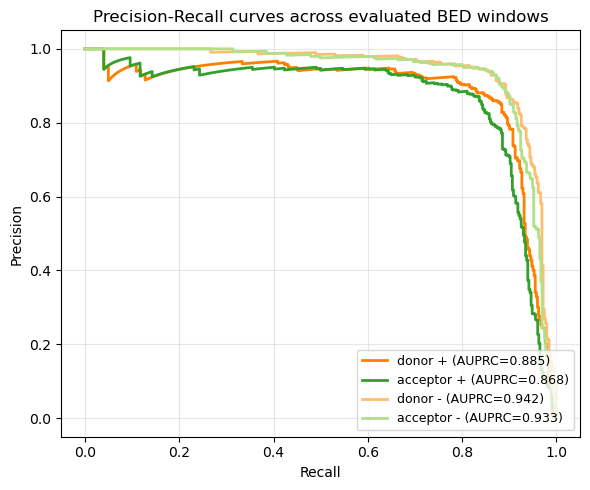

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

for cls_idx in range(len(SPLICE_CLASS_NAMES)):
    binary = (all_true_classes == cls_idx).astype(int)
    if binary.sum() == 0:
        continue
    prec, rec, _ = precision_recall_curve(binary, all_probs[:, cls_idx])
    auprc = average_precision_score(binary, all_probs[:, cls_idx])
    ax.plot(rec, prec, color=CLASS_COLORS[cls_idx], lw=2,
            label=f"{CLASS_LABELS[cls_idx]} (AUPRC={auprc:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
ax.set_title("Precision-Recall curves across evaluated BED windows")
plt.tight_layout()
plt.show()

## Usage alpha: correct vs incorrect predictions

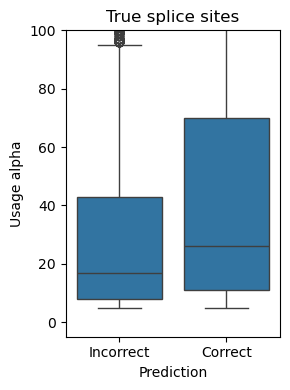

In [7]:
if all_alphas:
    import seaborn as sns
    alpha_df = pd.DataFrame(all_alphas).dropna(subset=["alpha"])
    # Only keep sites where the true label is not background
    if len(all_true_classes) == len(alpha_df):
        mask = all_true_classes != BACKGROUND_CLASS
        alpha_df = alpha_df[mask]
    fig, ax = plt.subplots(figsize=(3, 4))
    sns.boxplot(x="correct", y="alpha", data=alpha_df, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_ylim(-5, 100)
    ax.set_xticklabels(["Incorrect", "Correct"])
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Usage alpha")
    ax.set_title("True splice sites")
    plt.tight_layout()
    plt.show()
else:
    print("No usage alpha data collected (check usage_file path or column names)")